# Multi-harmonic fit

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import dill
from scipy.optimize import curve_fit

## Posterior samples

In [2]:
### get the posterior data
file_name = 'jnkep_fit_k2-19_nburn-1000_nsteps-1000_emax=0.5.pkl'

working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [3]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.44      0.06      0.45      0.35      0.52   1089.88      1.00
 ecosw_scaled[1]      0.47      0.04      0.47      0.40      0.53   1087.59      1.00
 esinw_scaled[0]      0.46      0.08      0.47      0.34      0.58    565.62      1.00
 esinw_scaled[1]      0.42      0.06      0.43      0.31      0.51    555.89      1.00
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    641.41      1.00
period_scaled[1]      0.51      0.01      0.51      0.50      0.52    763.49      1.00
 pmass_scaled[0]      0.11      0.01      0.10      0.10      0.11    510.85      1.01
 pmass_scaled[1]      0.04      0.00      0.04      0.04      0.04   1047.51      1.01
   tic_scaled[0]      0.50      0.00      0.50      0.49      0.50   1985.31      1.00
   tic_scaled[1]      0.52      0.01      0.52      0.49      0.53   1548.75      1.00

Number of divergences: 198


In [4]:
# Posterior samples
posterior_samples = mcmc.get_samples()

# Shape of samples
print({k: v.shape for k, v in posterior_samples.items()})

samples = mcmc.get_samples()

{'ecc': (8000, 2), 'ecosw': (8000, 2), 'ecosw_scaled': (8000, 2), 'ediff': (8000,), 'esinw': (8000, 2), 'esinw_scaled': (8000, 2), 'period': (8000, 2), 'period_scaled': (8000, 2), 'pmass': (8000, 2), 'pmass_scaled': (8000, 2), 'tcmodel': (8000, 33), 'tic': (8000, 2), 'tic_scaled': (8000, 2)}


In [5]:
### conversions
solar_mass_2_kg = 1.989e30 # [kg per solar mass]
d_2_s = 86400 # [seconds per day]

### system constants 
m_star = 0.88  # [solar mass]

from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.AU**3 / u.M_sun / u.day**2).value


### posterior samples 
ecosw_b = samples["ecosw"][:, 0]
esinw_b = samples["esinw"][:, 0]
# e_b = samples["ecc"][:,0]
Per_b = samples["period"][:,0] # [days]
Tc_b = samples["tic"][:,0] # [days]
m_b = samples["pmass"][:,0] # [solar mass]

ecosw_c = samples["ecosw"][:, 1]
esinw_c = samples["esinw"][:, 1]
# e_c = samples["ecc"][:,1]
Per_c = samples["period"][:,1] # [days]
Tc_c = samples["tic"][:,1] # [days]
m_c = samples["pmass"][:,1] # [solar mass]  


# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_b = np.sqrt(ecosw_b**2 + esinw_b**2)
omega_rad_b = np.arctan2(esinw_b, ecosw_b)
omega_deg_b = np.rad2deg(omega_rad_b)

# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_c = np.sqrt(ecosw_c**2 + esinw_c**2)
omega_rad_c = np.arctan2(esinw_c, ecosw_c)
omega_deg_c = np.rad2deg(omega_rad_c)


### keep Omega constant
value_Omega_b = 0  # [deg]
Omega_b = [np.radians(value_Omega_b)] * len(omega_rad_b)  # [rad]
value_Omega_c = 0 # [deg]
Omega_c = [np.radians(value_Omega_c)] * len(omega_rad_c)  # [rad]

pomega_rad_b = omega_rad_b + Omega_b
pomega_rad_c = omega_rad_c + Omega_c


Delta_omega_rad = omega_rad_c - omega_rad_b
Delta_omega_deg = omega_deg_c - omega_deg_b
print(omega_deg_b)
print(omega_deg_c)
print(np.median(Delta_omega_deg))
print(np.median(ecc_b))
print(np.median(ecc_c))


[  90.55521   88.37833  101.63964 ... -156.88086 -158.19621 -131.9418 ]
[  38.15789    31.793657   83.66336  ...  -99.690254 -108.53419
 -106.37444 ]
14.518337
0.09561829
0.09719007


## Transit time data

In [6]:
### get data from jnkepler fit
import json

# Load the data from the JSON file
with open("jnkep_fit_data.json", "r") as f:
    data = json.load(f)
# Access values just like a dictionary
# t_jnkep_b = data["jnkep_model_times"]["b"]
# t_jnkep_c = data["jnkep_model_times"]["c"]

t_obs_b = data["jnkep_observed_times"]["b"]
t_obs_c = data["jnkep_observed_times"]["c"]

t_obs_err_b = data["jnkep_observed_times_err"]["b"]
t_obs_err_c = data["jnkep_observed_times_err"]["c"]

index_obs_b = data["jnkep_observed_index"]["b"]
index_obs_c = data["jnkep_observed_index"]["c"]

# Ensure these are numpy arrays
index_obs_b = np.array(index_obs_b)
index_obs_c = np.array(index_obs_c)

t_obs_b = np.array(t_obs_b)
t_obs_c = np.array(t_obs_c)
t_obs_err_b = np.array(t_obs_err_b)
t_obs_err_c = np.array(t_obs_err_c)

## Multi-harmonic fit 

In [7]:
### from Lithwick et al. 2012
### TTV period 
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

def delta_(P1, P2, j):
    d = ((P2/P1)*((j-1)/j)) - 1
    return d


In [8]:
j = 3 # 3:2 MMR
p_b = np.median(Per_b)
p_c = np.median(Per_c)
tc_b = np.median(Tc_b)
tc_c = np.median(Tc_c)


delta = delta_(p_b, p_c, j)
print(f'delta: {delta}')

ttv_period = ttv_per(p_c, j, delta)
print(f'TTV period: {ttv_period} days')

delta: 0.0023067792256672437
TTV period: 1720.496106938662 days


In [9]:
# t_b = t_b_0 + P_b*i_b + A_bc*np.sin((2*np.pi)/(P_bc*(t-t_bc_0)))
# def model_b(t, t_b_0, P_b, i_b, A_bc, P_bc, t_bc_0):
#     t_b = t_b_0 + P_b*i_b + A_bc*np.sin((2*np.pi)/(P_bc*(t-t_bc_0)))  
#     return t_b


# # t_c = t_c_0 + P_c*i_c + A_cb*np.sin((2*np.pi)/(P_cb*(t-t_cb_0)))
# def model_c(t, t_c_0, P_c, i_c, A_cb, P_cb, t_cb_0):
#     t_c = t_c_0 + P_c*i_c + A_cb*np.sin((2*np.pi)/(P_cb*(t-t_cb_0)))
#     return t_c
### we set P_bc = P_cb and t_bc_0 = t_cb_0

In [10]:
def model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    return t_linear + A_bc * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    return t_linear + A_cb * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = params

    ### define models
    t_model_b = model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0)

    ### find residuals
    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])



In [11]:
### let 8 params vary: t_b_0, P_b, A_bc, P_bc, t_bc, t_c_0, P_c, A_cb

In [12]:
# Initial guesses for parameters
initial_t_b0 = tc_b
initial_P_b = p_b
initial_A_bc = .012    ####
initial_t_c0 = tc_c
initial_P_c = p_c
initial_A_cb =  0.2   ####
initial_P_cb = 1000 #ttv_period
initial_t_cb0 = tc_b   ###

initial_params = [initial_t_b0, initial_P_b, initial_A_bc, initial_t_c0, 
                  initial_P_c, initial_A_cb, initial_P_cb, initial_t_cb0]


In [13]:
from scipy.optimize import least_squares


### Run the fit (fitting residuals)
result = least_squares(
    residuals,
    initial_params,
    args=(index_obs_b, t_obs_b, t_obs_err_b, index_obs_c, t_obs_c, t_obs_err_c),
    method='trf'
)

fitted_params = result.x
print(fitted_params)

### unpack fit params
t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = fitted_params

[ 2.02792346e+03  7.92085954e+00 -3.02294454e-02  2.01991540e+03
  1.18991997e+01  1.15280601e-01  7.82183711e+02  1.91793665e+03]


In [14]:
from numpy.linalg import inv
### errors on fit 
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))

In [15]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "A_bc", "t_c0", "P_c", "A_cb", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 2027.92346284 ± 0.00065708
   P_b = 7.92085954 ± 0.00002078
  A_bc = -0.03022945 ± 0.00087486
  t_c0 = 2019.91540317 ± 0.00336289
   P_c = 11.89919967 ± 0.00011051
  A_cb = 0.11528060 ± 0.00391731
  P_cb = 782.18371070 ± 9.08159602
 t_cb0 = 1917.93665103 ± 2.05565571


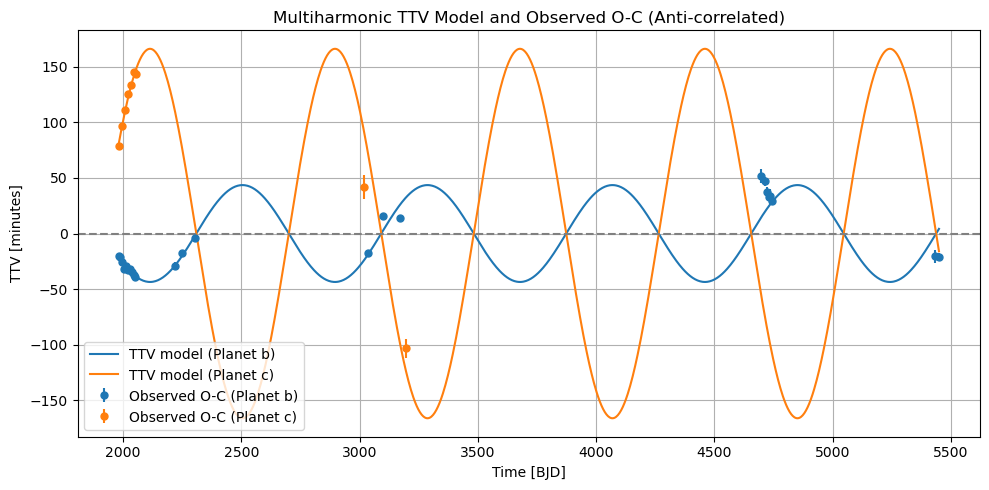

In [16]:
# Combine observed times to set the time range
all_times = np.concatenate([t_obs_b, t_obs_c])
t_dense = np.linspace(np.min(all_times), np.max(all_times), 1000)

# Compute "virtual" transit indices for continuous times
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c

# Linear ephemerides
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# Anti-correlated TTV signals: negate one amplitude!
ttv_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_b - t_cb0)) * 1440
ttv_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_c - t_cb0)) * 1440  # <- NEGATE here

# Observed linear ephemerides
t_lin_obs_b = t_b0 + P_b * np.array(index_obs_b)
t_lin_obs_c = t_c0 + P_c * np.array(index_obs_c)

# Observed O-C residuals in minutes
oc_b = (np.array(t_obs_b) - t_lin_obs_b) * 1440
oc_c = (np.array(t_obs_c) - t_lin_obs_c) * 1440

# Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(t_dense, ttv_b, label="TTV model (Planet b)", color='tab:blue')
plt.plot(t_dense, ttv_c, label="TTV model (Planet c)", color='tab:orange')

plt.errorbar(t_lin_obs_b, oc_b, yerr=np.array(t_obs_err_b)*1440, fmt='o',
             color='tab:blue', label='Observed O-C (Planet b)', markersize=5)
plt.errorbar(t_lin_obs_c, oc_c, yerr=np.array(t_obs_err_c)*1440, fmt='o',
             color='tab:orange', label='Observed O-C (Planet c)', markersize=5)

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Time [BJD]")
plt.ylabel("TTV [minutes]")
plt.title("Multiharmonic TTV Model and Observed O-C (Anti-correlated)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


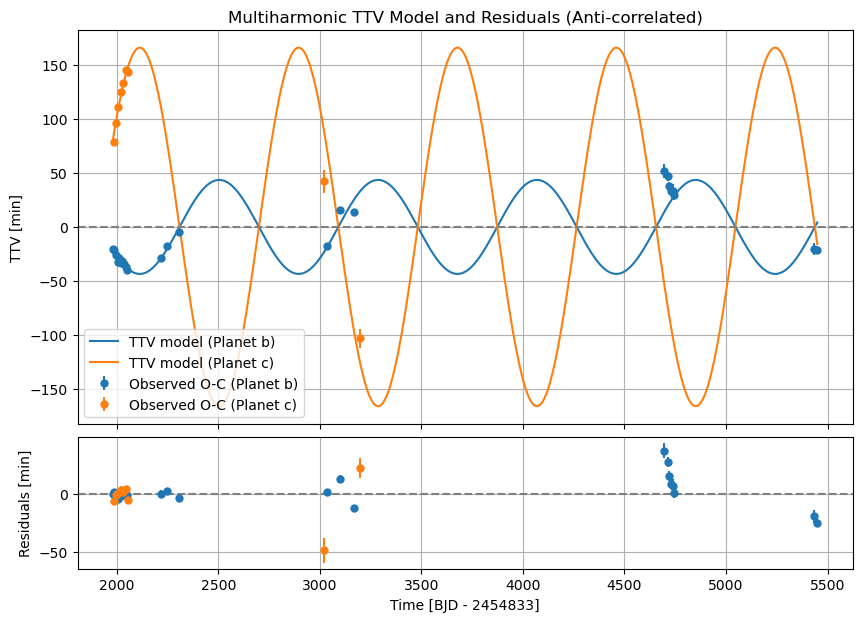

In [17]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Predict TTV model at observed times (for residuals)
ttv_model_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_obs_b - t_cb0)) * 1440
ttv_model_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_obs_c - t_cb0)) * 1440

# Residuals: (observed O-C) - (model TTV)
residuals_b = oc_b - ttv_model_b
residuals_c = oc_c - ttv_model_c

# Plot with subpanels: main TTV + residuals
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# TTV Model and Observations
ax1 = fig.add_subplot(gs[0])

ax1.plot(t_dense, ttv_b, label="TTV model (Planet b)", color='tab:blue')
ax1.plot(t_dense, ttv_c, label="TTV model (Planet c)", color='tab:orange')

ax1.errorbar(t_lin_obs_b, oc_b, yerr=np.array(t_obs_err_b)*1440, fmt='o',
             color='tab:blue', label='Observed O-C (Planet b)', markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=np.array(t_obs_err_c)*1440, fmt='o',
             color='tab:orange', label='Observed O-C (Planet c)', markersize=5)

ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("TTV [min]")
ax1.set_title("Multiharmonic TTV Model and Residuals (Anti-correlated)")
ax1.tick_params(labelbottom=False) 
ax1.legend()
ax1.grid(True)

# Residuals Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_lin_obs_b, residuals_b, yerr=np.array(t_obs_err_b)*1440, fmt='o',
             color='tab:blue', markersize=5, label="Residuals (b)")
ax2.errorbar(t_lin_obs_c, residuals_c, yerr=np.array(t_obs_err_c)*1440, fmt='o',
             color='tab:orange', markersize=5, label="Residuals (c)")

ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [min]")
ax2.grid(True)

# plt.tight_layout()
plt.show()


## Using other method

In [18]:
k=3
f1 = -2.025
f2 = 2.484

def nes_ttv_per(P1, P2, P_tau, m1, m2, m_star, k, f1, f2):
    term1 = (P1+P2)/2
    term2 = P_tau / (2*np.pi)
    term3 = ((m1+m2)/m_star)**(-2./3.)
    term4 = ((3./2.)*k*(k-1)*np.abs(f1)*f2)**(-1./3.)
    per = term1 * term2 * term3 * term4
    return per



## Lithwick method

In [19]:
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

def delta_(P1, P2, j):
    d = ((P2/P1)*((j-1)/j)) - 1
    return d

def ttv_amp_1(P1, m2, m_star, j, delta, f, Z_free):
    term1_num = m2/m_star
    term1_den = np.pi * j**(2./3.) * (j-1)**(1./3.) * delta
    term1 = term1_num / term1_den
    term2 = -f - ((3*Z_free.conjugate())/(2*delta))
    ttv_amp = P1 * term1 * term2
    return ttv_amp

def ttv_amp_2(P2, m1, m_star, j, delta, g, Z_free):
    term1_num = m1/m_star
    term1_den = np.pi * j * delta
    term1 = term1_num / term1_den
    term2 = -g - ((3*Z_free.conjugate())/2*delta)
    ttv_amp = P2 * term1 * term2
    return ttv_amp

def z_free_k(ek, pomega_k):
    z = ek*np.cos(pomega_k) + 1j*ek*np.sin(pomega_k)
    return z

def Z_free_(z_free_1, z_free_2, f, g):
    Z_free = f*z_free_1 + g*z_free_2
    return Z_free

In [20]:
### for 3:2 MMR
f = -2.025
g = 2.484
j=3


In [21]:
z_free_b = z_free_k(ecc_b, omega_rad_b)
print(z_free_b)
z_free_c = z_free_k(ecc_c, omega_rad_c)
print(z_free_c)
Z_free = Z_free_(z_free_b, z_free_c, f, g)
print(Z_free)
delta = delta_(Per_b, Per_c, j)
print(delta)
ttv_period = ttv_per(Per_c, j, delta)
print(ttv_period)


[-0.00071565+0.07385008j  0.00206812+0.0730501j  -0.01410795+0.06848793j
 ... -0.02885995-0.0123212j  -0.04358279-0.0174352j
 -0.05371934-0.05978336j]
[ 0.01064123+0.00836117j  0.01287562+0.00798125j  0.00043922+0.00395521j
 ... -0.01048406-0.06139714j -0.02199337-0.06560114j
 -0.02965585-0.1009281j ]
[0.02788202-0.12877728j 0.0277951 -0.12810102j 0.02965963-0.1288633j  ...
 0.03239898-0.12756006j 0.03362361-0.12764694j 0.03511655-0.1296441j ]
[0.00251532 0.00250912 0.00248265 ... 0.00238073 0.00233769 0.00226796]
[1578.1157 1582.0101 1598.8422 ... 1667.1512 1697.7738 1749.8906]


In [22]:
ttv_amp_b = ttv_amp_1(Per_b, m_c, m_star, j, delta, f, Z_free)
print(ttv_amp_b)

ttv_amp_c = ttv_amp_2(Per_c, m_b, m_star, j, delta, g, Z_free)
print(ttv_amp_c)

[-0.2329962 -1.2253616j -0.2304917 -1.2097046j -0.25253415-1.2369748j ...
 -0.30930406-1.3518877j -0.34537467-1.4469745j -0.38429984-1.5542816j]
[-0.14471854-2.8305922e-05j -0.14485379-2.8114138e-05j
 -0.14768127-2.8529294e-05j ... -0.15289071-2.8036589e-05j
 -0.15534712-2.7991126e-05j -0.16511464-2.9315133e-05j]


## Nesvorny method

In [23]:
def ttv_signal_k(P_k, lambda_variation_k, h_variation_k):
    n_k = (2*np.pi) / P_k
    ttv_signal = (1 / n_k) * (-lambda_variation_k + 2*h_variation_k)
    return ttv_signal

def ttv_signal_k(lambda_variation_k, h_variation_k):
    ttv_signal = lambda_variation_k + h_variation_k
    return ttv_signal

### -1/n1 * var_lambda1
def lambda_var_1(t, k, Lambda_1, nu, P_tau, A_psi, eps, f):
    term1_num = 3*(k-1)
    term1_den = Lambda_1 * nu
    term2 = (P_tau / (2*np.pi))
    term3 = A_psi
    term4_1 = (1+eps)*np.sin(f*t)
    term4_2 = (eps/4)*np.sin(2*f*t)
    term4 = term4_1 - term4_2
    lambda_var = term1 * term2 * term3 * term4
    return lambda_var

### -1/n2 * var_lambda2
def lambda_var_2(t, k, Lambda_2, nu, P_tau, A_psi, eps, f):
    term1_num = -3*k
    term1_den = Lambda_2 * nu
    term2 = (P_tau / (2*np.pi))
    term3 = A_psi
    term4_1 = (1+eps)*np.sin(f*t)
    term4_2 = (eps/4)*np.sin(2*f*t)
    term4 = term4_1 - term4_2
    lambda_var = term1 * term2 * term3 * term4
    return lambda_var


### 2/n1 * var_h_1
def h_var_1(t, P_1, nu, C, Lambda_1, Lambda_2, A_psi, C_u0, theta_initial, f_theta):
    heta1 = nu / C
    A = f_1 / np.sqrt(Lambda_1)
    B = f_2 / np.sqrt(Lambda_2)
    
    term1_num = P_1 * heta1**(-1./3.)
    term1_den = np.pi*np.sqrt(Lambda_1)
    term1 = term1_num / term1_den
    
    term2_num = A * A_psi
    term2_den = np.sqrt(A**2 + B**2)
    term2 = term2_num / term2_den
    term3 = C_u0
    
    term4 = np.sin(theta_initial + f_theta*t)
    h_var = term1 * term2 * term3 * term4
    return h_var

### 2/n2 * var_h_2
def h_var_1(t, P_2, nu, C, Lambda_1, Lambda_2, A_psi, C_u0, theta_initial, f_theta):
    heta1 = nu / C
    A = f_1 / np.sqrt(Lambda_1)
    B = f_2 / np.sqrt(Lambda_2)
    
    term1_num = P_2 * heta1**(-1./3.)
    term1_den = np.pi*np.sqrt(Lambda_2)
    term1 = term1_num / term1_den
    
    term2_num = B * A_psi
    term2_den = np.sqrt(A**2 + B**2)
    term2 = term2_num / term2_den
    
    term3 = C_u0
    term4 = np.sin(theta_initial + f_theta*t)
    h_var = term1 * term2 * term3 * term4
    return h_var



def nu_(k, P_1, P_2, Lambda_1, Lambda_2):
    n1 = (2*np.pi) / P_1
    n2 = (2*np.pi) / P_2
    term1 = (k-1)**2 * (n1 / Lambda_1)
    term2 = k**2 * (n2 / Lambda_2)
    nu = (3/2) * (term1 + term2)
    return nu

def Lambda_k(m_k, G, m_star, a_k):
    Lambda = m_k * np.sqrt(G*m_star*a_k)
    return Lambda

def f_(nu, C, P_tau):
    term1 = nu*C**2
    term2 = (2*np.pi) / P_tau
    f = term1**(1./3.) * term2
    return f

def C_(m_1, m_2, a_2, G, f_1, f_2, Lambda_1, Lambda_2):
    term1_num = G*m_1*m_2
    term1_den = a_2
    term1 = term1_num / term1_den
    term2_1 = f_1**2 / Lambda_1
    term2_2 = f_2**2 / Lambda_2
    term2 = np.sqrt(term2_1 + term2_2)
    C = term1 * term2
    return C

def theta_(k, lambda_1, lambda_2):
    theta = k*lambda_2 - (k-1)*lambda_1
    return theta



In [24]:
### for 3:2
f_1 = -2.025
f_2 = 2.484
k=3

### try simpler approximation of nesvorny

In [25]:
def model_b(i_b, t_b0, P_b,
            A_bc_s, P_cb_s, t_cb0_s,
            A_bc_l, P_cb_l, t_cb0_l):
    t_linear = t_b0 + P_b * i_b
    return (
        t_linear
        + A_bc_s * np.sin((2 * np.pi / P_cb_s) * (t_linear - t_cb0_s))
        + A_bc_l * np.sin((2 * np.pi / P_cb_l) * (t_linear - t_cb0_l))
    )

def model_c(i_c, t_c0, P_c,
            A_cb_s, P_cb_s, t_cb0_s,
            A_cb_l, P_cb_l, t_cb0_l):
    t_linear = t_c0 + P_c * i_c
    return (
        t_linear
        + A_cb_s * np.sin((2 * np.pi / P_cb_s) * (t_linear - t_cb0_s))
        + A_cb_l * np.sin((2 * np.pi / P_cb_l) * (t_linear - t_cb0_l))
    )

In [26]:
def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    (t_b0, P_b,
     A_bc_s, A_bc_l,
     t_c0, P_c,
     A_cb_s, A_cb_l,
     P_cb_s, t_cb0_s,
     P_cb_l, t_cb0_l) = params

    t_model_b = model_b(i_b, t_b0, P_b,
                        A_bc_s, P_cb_s, t_cb0_s,
                        A_bc_l, P_cb_l, t_cb0_l)

    t_model_c = model_c(i_c, t_c0, P_c,
                        A_cb_s, P_cb_s, t_cb0_s,
                        A_cb_l, P_cb_l, t_cb0_l)

    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])


In [27]:
# Initial guesses for parameters
initial_t_b0 = tc_b
initial_P_b = p_b
initial_A_bc = 1/24   ####
initial_A_bc_l = 1/12

initial_t_c0 = tc_c
initial_P_c = p_c
initial_A_cb =  1/12   ####
initial_cb_l = 0.25

initial_P_cb = 700 #ttv_period
initial_t_cb0 = tc_b   ###
initial_P_cb_l = 2500
initial_t_cb0_l = tc_b
initial_params = [initial_t_b0, initial_P_b, initial_A_bc, initial_A_bc_l, 
                  initial_t_c0, initial_P_c, initial_A_cb, initial_cb_l, 
                  initial_P_cb, initial_t_cb0, initial_P_cb_l, initial_t_cb0_l]


In [28]:
from scipy.optimize import least_squares

# example: params0 = [initial guesses...]
# res = least_squares(residuals, initial_params, args=(i_b, t_obs_b, err_b, i_c, t_obs_c, err_c))
result = least_squares(
    residuals,
    initial_params,
    args=(index_obs_b, t_obs_b, t_obs_err_b, index_obs_c, t_obs_c, t_obs_err_c),
    method='trf'
)
fitted_params = result.x
print(fitted_params)


[ 2.02792463e+03  7.92089131e+00 -3.00070216e-02  4.58687632e-02
  2.01987079e+03  1.18996615e+01  1.51904290e-01 -1.36989846e-01
  7.29115774e+02  1.86617503e+03  2.65493819e+03  7.44602078e+02]


In [36]:
### param errors:
J = result.jac  # Jacobian at the solution
residuals = result.fun
num_data_points = len(residuals)
num_params = len(fitted_params)
dof = num_data_points - num_params

# Step 2: Estimate variance of residuals
residual_variance = np.sum(residuals**2) / dof

# Step 3: Compute covariance matrix
cov = np.linalg.inv(J.T @ J) * residual_variance

# Step 4: Compute parameter errors
param_errors = np.sqrt(np.diag(cov))

In [29]:
# Unpack fitted parameters
(t_b0_fit, P_b_fit,
 A_bc_s_fit, A_bc_l_fit,
 t_c0_fit, P_c_fit,
 A_cb_s_fit, A_cb_l_fit,
 P_cb_s_fit, t_cb0_s_fit,
 P_cb_l_fit, t_cb0_l_fit) = fitted_params

# Compute model predictions
t_model_b = model_b(index_obs_b, t_b0_fit, P_b_fit,
                    A_bc_s_fit, P_cb_s_fit, t_cb0_s_fit,
                    A_bc_l_fit, P_cb_l_fit, t_cb0_l_fit)

t_model_c = model_c(index_obs_c, t_c0_fit, P_c_fit,
                    A_cb_s_fit, P_cb_s_fit, t_cb0_s_fit,
                    A_cb_l_fit, P_cb_l_fit, t_cb0_l_fit)


In [30]:
ttv_obs_b = t_obs_b - (t_b0_fit + P_b_fit * index_obs_b)
ttv_model_b = t_model_b - (t_b0_fit + P_b_fit * index_obs_b)

ttv_obs_c = t_obs_c - (t_c0_fit + P_c_fit * index_obs_c)
ttv_model_c = t_model_c - (t_c0_fit + P_c_fit * index_obs_c)

In [31]:
# Time range based on your observations
t_min = min(t_obs_b.min(), t_obs_c.min())
t_max = max(t_obs_b.max(), t_obs_c.max())

# Generate a dense time grid (e.g., 1000 points)
t_dense = np.linspace(t_min, t_max, 1000)

# Interpolate fractional indices (you can reverse the linear ephemeris to get i)
i_dense_b = (t_dense - t_b0_fit) / P_b_fit
i_dense_c = (t_dense - t_c0_fit) / P_c_fit


In [32]:
# Linear component 
t_linear_b = t_b0_fit + P_b_fit * i_dense_b
t_linear_c = t_c0_fit + P_c_fit * i_dense_c

# Short-period components
ttv_b_short = A_bc_s_fit * np.sin((2 * np.pi / P_cb_s_fit) * (t_linear_b - t_cb0_s_fit))
ttv_c_short = A_cb_s_fit * np.sin((2 * np.pi / P_cb_s_fit) * (t_linear_c - t_cb0_s_fit))

# Long-period components
ttv_b_long = A_bc_l_fit * np.sin((2 * np.pi / P_cb_l_fit) * (t_linear_b - t_cb0_l_fit))
ttv_c_long = A_cb_l_fit * np.sin((2 * np.pi / P_cb_l_fit) * (t_linear_c - t_cb0_l_fit))

# Total TTV (just for reference)
ttv_b_total = ttv_b_short + ttv_b_long
ttv_c_total = ttv_c_short + ttv_c_long

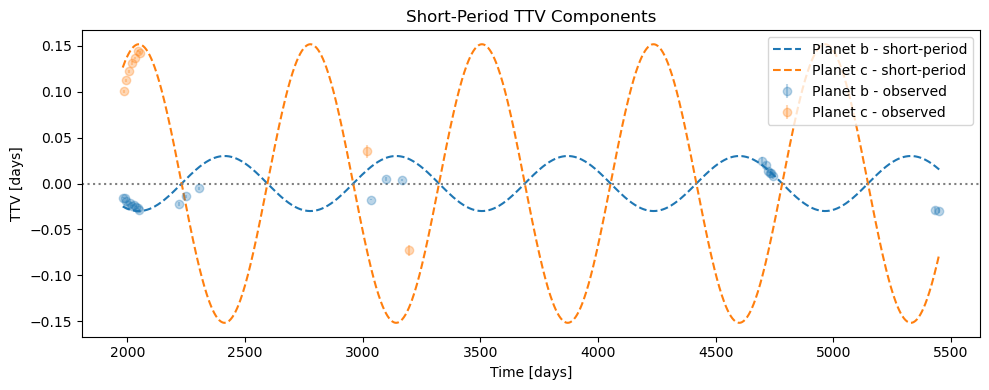

In [33]:
plt.figure(figsize=(10, 4))

# Short-period TTVs
plt.plot(t_dense, ttv_b_short, label='Planet b - short-period', linestyle='--', color='C0')
plt.plot(t_dense, ttv_c_short, label='Planet c - short-period', linestyle='--', color='C1')

# Optional: overlay observed TTVs (faint)
plt.errorbar(t_obs_b, ttv_obs_b, yerr=t_obs_err_b, fmt='o', color='C0', alpha=0.3, label='Planet b - observed')
plt.errorbar(t_obs_c, ttv_obs_c, yerr=t_obs_err_c, fmt='o', color='C1', alpha=0.3, label='Planet c - observed')

plt.axhline(0, color='gray', linestyle=':')
plt.title("Short-Period TTV Components")
plt.xlabel("Time [days]")
plt.ylabel("TTV [days]")
plt.legend()
plt.tight_layout()
plt.show()

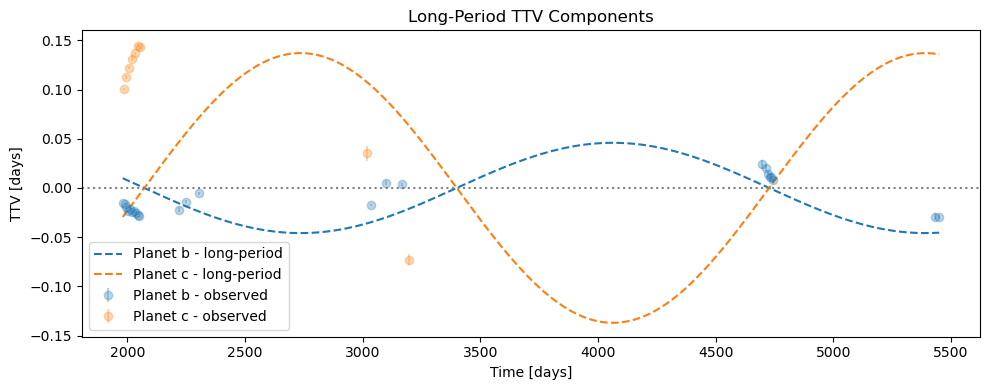

In [34]:
plt.figure(figsize=(10, 4))

# Long-period TTVs
plt.plot(t_dense, ttv_b_long, label='Planet b - long-period', linestyle='--', color='C0')
plt.plot(t_dense, ttv_c_long, label='Planet c - long-period', linestyle='--', color='C1')

# Optional: overlay observed TTVs (faint)
plt.errorbar(t_obs_b, ttv_obs_b, yerr=t_obs_err_b, fmt='o', color='C0', alpha=0.3, label='Planet b - observed')
plt.errorbar(t_obs_c, ttv_obs_c, yerr=t_obs_err_c, fmt='o', color='C1', alpha=0.3, label='Planet c - observed')

plt.axhline(0, color='gray', linestyle=':')
plt.title("Long-Period TTV Components")
plt.xlabel("Time [days]")
plt.ylabel("TTV [days]")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

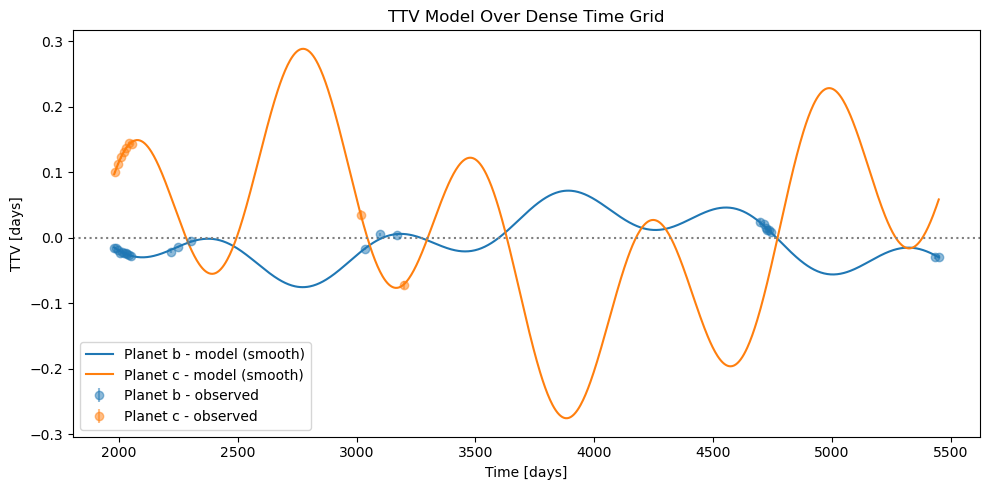

In [35]:
plt.figure(figsize=(10, 5))

plt.figure(figsize=(10, 5))

# Planet b
plt.plot(t_dense, ttv_b_short + ttv_b_long, label='Planet b - model (smooth)', color='C0')
plt.errorbar(t_obs_b, ttv_obs_b, yerr=t_obs_err_b, fmt='o', label='Planet b - observed', color='C0', alpha=0.5)

# Planet c
plt.plot(t_dense, ttv_c_short + ttv_c_long, label='Planet c - model (smooth)', color='C1')
plt.errorbar(t_obs_c, ttv_obs_c, yerr=t_obs_err_c, fmt='o', label='Planet c - observed', color='C1', alpha=0.5)

plt.axhline(0, color='gray', linestyle=':')
plt.xlabel("Time [days]")
plt.ylabel("TTV [days]")
plt.title("TTV Model Over Dense Time Grid")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_7900/2875509706.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


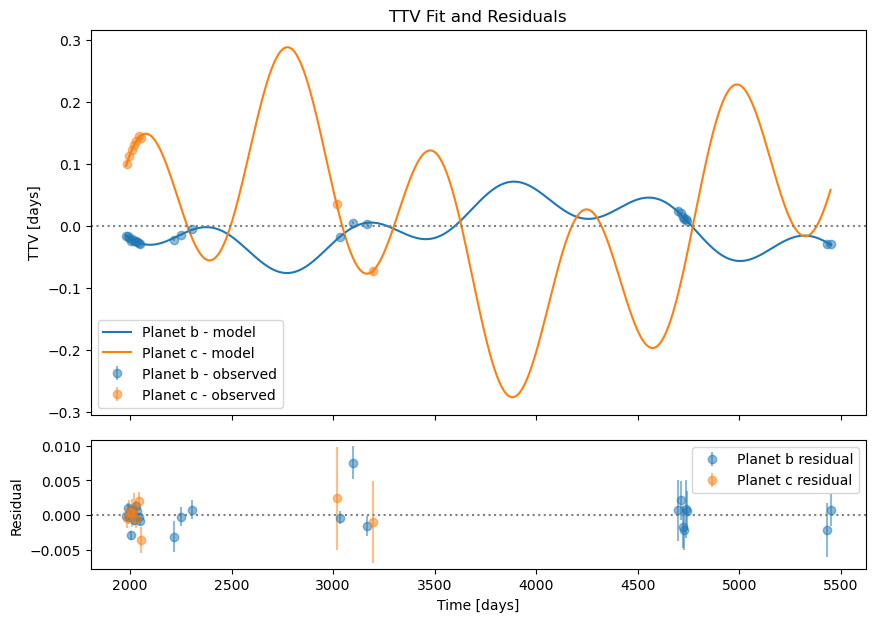

In [40]:
import matplotlib.gridspec as gridspec

# Compute model predictions at observed times
t_model_b_obs = model_b(index_obs_b, t_b0_fit, P_b_fit,
                        A_bc_s_fit, P_cb_s_fit, t_cb0_s_fit,
                        A_bc_l_fit, P_cb_l_fit, t_cb0_l_fit)
t_model_c_obs = model_c(index_obs_c, t_c0_fit, P_c_fit,
                        A_cb_s_fit, P_cb_s_fit, t_cb0_s_fit,
                        A_cb_l_fit, P_cb_l_fit, t_cb0_l_fit)

# Compute residuals: observed - model (already normalized earlier)
res_b = ttv_obs_b - (t_model_b_obs - (t_b0_fit + P_b_fit * index_obs_b))
res_c = ttv_obs_c - (t_model_c_obs - (t_c0_fit + P_c_fit * index_obs_c))

# Setup figure with two vertically stacked plots
fig = plt.figure(figsize=(10, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)

# ----- Top: Model + Data -----
ax1 = fig.add_subplot(gs[0])

# Planet b
ax1.plot(t_dense, ttv_b_short + ttv_b_long, label='Planet b - model', color='C0')
ax1.errorbar(t_obs_b, ttv_obs_b, yerr=t_obs_err_b, fmt='o', label='Planet b - observed', color='C0', alpha=0.5)

# Planet c
ax1.plot(t_dense, ttv_c_short + ttv_c_long, label='Planet c - model', color='C1')
ax1.errorbar(t_obs_c, ttv_obs_c, yerr=t_obs_err_c, fmt='o', label='Planet c - observed', color='C1', alpha=0.5)

ax1.axhline(0, color='gray', linestyle=':')
ax1.set_ylabel("TTV [days]")
ax1.set_title("TTV Fit and Residuals")
ax1.legend()
ax1.tick_params(labelbottom=False)  # Hide x-axis labels here

# ----- Bottom: Residuals -----
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_obs_b, res_b, yerr=t_obs_err_b, fmt='o', color='C0', alpha=0.5, label='Planet b residual')
ax2.errorbar(t_obs_c, res_c, yerr=t_obs_err_c, fmt='o', color='C1', alpha=0.5, label='Planet c residual')

ax2.axhline(0, color='gray', linestyle=':')
ax2.set_xlabel("Time [days]")
ax2.set_ylabel("Residual")
ax2.legend()

plt.tight_layout()
plt.show()

In [41]:
param_names = [
    "t_b0", "P_b", "A_bc_s", "A_bc_l",
    "t_c0", "P_c", "A_cb_s", "A_cb_l",
    "P_cb_s", "t_cb0_s", "P_cb_l", "t_cb0_l"
]

print("\nFitted Parameters and 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:10s} = {val: .8f} ± {err:.8f}")


Fitted Parameters and 1σ Uncertainties:

t_b0       =  2027.92463251 ± 0.00421540
P_b        =  7.92089131 ± 0.00006357
A_bc_s     = -0.03000702 ± 0.00298918
A_bc_l     =  0.04586876 ± 0.01722290
t_c0       =  2019.87079081 ± 0.04468989
P_c        =  11.89966145 ± 0.00120828
A_cb_s     =  0.15190429 ± 0.03307676
A_cb_l     = -0.13698985 ± 0.11167554
P_cb_s     =  729.11577380 ± 9.53605903
t_cb0_s    =  1866.17502843 ± 20.36005084
P_cb_l     =  2654.93818618 ± 136.34978290
t_cb0_l    =  744.60207759 ± 110.96729972
